# Learning curves i dataanalyse

En learning curve viser hvordan feilen endrer seg når modellen får mer data eller øker i kompleksitet.

- Training error: feilen på de dataene modellen faktisk trenes på. Denne faller vanligvis når modellen får mer informasjon eller blir mer fleksibel.
- Cross-validation error: feilen på data som modellen ikke har sett under trening. Denne er viktig for å se om modellen generaliserer, ikke bare memoriserer treningsdata.

Typisk ser vi at train error synker med mer data eller flere komponenter, mens CV error først synker og deretter flater ut eller stiger hvis modellen begynner å overfitte.

Nedenfor er noen illustrative eksempler på slike kurver.


## PLS-modell for diabetes-datasettet

Nå bruker vi `sklearn`-datasettet `diabetes` for å gjøre en liten PLS-analyse.

Vi deler dataene i en treningsmengde (80 %) og en testmengde (20 %). Deretter fitter vi PLS-modeller med 1 til 10 komponenter, og sammenligner treningsfeil, kryssvalideringsfeil og testfeil for å lage en kompleksitetskurve.


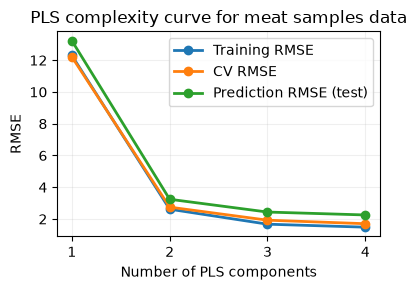

n_components | train_rmse | cv_rmse | test_rmse
           1 |    12.2988 |  12.2107 |  13.2298
           2 |     2.6174 |   2.7468 |   3.2423
           3 |     1.6733 |   1.9249 |   2.4372
           4 |     1.4850 |   1.7033 |   2.2539


In [49]:
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

data = fetch_openml(data_id=505, as_frame=False)
X, y = data.data, data.target.astype(float)
# X: (215, 100), y: fat content



# Del data i trenings- og testmengde (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

n_components = range(1, 5)
train_rmse = []
cv_rmse = []
test_rmse = []

for n in n_components:
    pls = PLSRegression(n_components=n)

    # Tren på treningsdata
    pls.fit(X_train, y_train)
    y_train_pred = pls.predict(X_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))

    # Kryssvalidering på treningsdata
    scores = cross_val_score(
        pls,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=None,
    )
    cv_rmse.append(-scores.mean())

    # Test-feil på de 20 % som aldri ble brukt i modellbygging
    y_test_pred = pls.predict(X_test)
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

# Plot kompleksitetskurve
plt.figure(figsize=(4, 3))
plt.plot(list(n_components), train_rmse, marker='o', linewidth=2, label='Training RMSE')
plt.plot(list(n_components), cv_rmse, marker='o', linewidth=2, label='CV RMSE')
plt.plot(list(n_components), test_rmse, marker='o', linewidth=2, label='Prediction RMSE (test)')

plt.xlabel('Number of PLS components')
plt.ylabel('RMSE')
plt.title('PLS complexity curve for meat samples data')
plt.xticks(list(n_components))
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# Vis de beste komponentene i tabellform
results = list(zip(list(n_components), train_rmse, cv_rmse, test_rmse))
print('n_components | train_rmse | cv_rmse | test_rmse')
for row in results:
    print(f'{row[0]:>12} | {row[1]:>10.4f} | {row[2]:>8.4f} | {row[3]:>8.4f}')


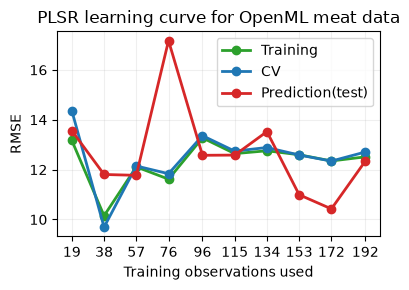

n_train | train_rmse | cv_rmse | pred_rmse
     19 |    13.1680 |  14.3612 |    13.5611
     38 |    10.1488 |   9.6915 |    11.8047
     57 |    12.1093 |  12.1458 |    11.7709
     76 |    11.6168 |  11.8357 |    17.1718
     96 |    13.2737 |  13.3612 |    12.5742
    115 |    12.6415 |  12.7411 |    12.5823
    134 |    12.7553 |  12.8865 |    13.5238
    153 |    12.5959 |  12.5856 |    10.9915
    172 |    12.3466 |  12.3424 |    10.4246
    192 |    12.5120 |  12.7068 |    12.3421


In [52]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Hent OpenML-datasettet
# Dette er datasettet "meat" med mål på fettinnhold
# (similar to the spectroscopy example)
data = fetch_openml(data_id=505, as_frame=False)
X, y = data.data, data.target.astype(float)

# Definer prosentandelene av data som skal brukes
fractions = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 1.00]
rng = np.random.RandomState(42)
train_rmse = []
cv_rmse = []
pred_rmse = []
obs_used = []

for frac in fractions:
    n_samples = max(1, int(round(len(X) * frac)))
    idx = rng.choice(len(X), size=n_samples, replace=False)
    X_sub = X[idx]
    y_sub = y[idx]

    # Del inn i trenings- og testmengde (80/20) for hver delmengde
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub,
        y_sub,
        test_size=0.2,
        random_state=42,
    )

    pls = PLSRegression(n_components=1)

    # Treningsfeil
    pls.fit(X_train, y_train)
    y_train_pred = pls.predict(X_train)
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))

    # Kryssvalidering på treningsdata
    cv_scores = cross_val_score(
        pls,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=None,
    )
    cv_rmse.append(-cv_scores.mean())

    # Modell brukes på testdata
    y_pred = pls.predict(X_test)
    pred_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    obs_used.append(len(X_train))

# Plot learning curve: error vs. antall observasjoner i treningsdata
plt.figure(figsize=(4, 3))
plt.plot(obs_used, train_rmse, marker='o', linewidth=2, color='tab:green', label='Training')
plt.plot(obs_used, cv_rmse, marker='o', linewidth=2, color='tab:blue', label='CV')
plt.plot(obs_used, pred_rmse, marker='o', linewidth=2, color='tab:red', label='Prediction(test)')
plt.xlabel('Training observations used')
plt.ylabel('RMSE')
plt.title('PLSR learning curve for OpenML meat data')
plt.xticks(obs_used)
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

print('n_train | train_rmse | cv_rmse | pred_rmse')
for n, tr_err, cv_err, pred_err in zip(obs_used, train_rmse, cv_rmse, pred_rmse):
    print(f'{n:>7} | {tr_err:>10.4f} | {cv_err:>8.4f} | {pred_err:>10.4f}')